In [ ]:
# Standard imports for analysis and modelling
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import joblib
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings("ignore")

sns.set(style='whitegrid')
RSEED = 42
print("Imports complete.")


Imports complete.


In [ ]:
# Load the dataset. Change file_path if needed (e.g., '/content/drive/MyDrive/heart.csv' after mounting Drive)
file_path = "heart.csv"
if not os.path.exists(file_path):
    raise FileNotFoundError(f"{file_path} not found. Upload 'heart.csv' to Colab or change file_path.")

df = pd.read_csv(file_path)
print("Dataset loaded. Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())


Dataset loaded. Shape: (303, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1



Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [ ]:
print("Column names and quick meanings:")
cols = list(df.columns)
for c in cols:
    print("-", c)

print("\nTarget value counts (0 = no disease, 1 = disease):")
print(df['target'].value_counts())


Column names and quick meanings:
- age
- sex
- cp
- trestbps
- chol
- fbs
- restecg
- thalach
- exang
- oldpeak
- slope
- ca
- thal
- target

Target value counts (0 = no disease, 1 = disease):
target
1    165
0    138
Name: count, dtype: int64


In [ ]:
print("Summary statistics (numeric):")
display(df.describe().T)

print("\nObservations to note:")
print("- Check min/max for suspicious values (e.g., 'thal' or 'ca' sometimes encoded with 0 or missing).")
print("- Dataset rows:", df.shape[0])


Summary statistics (numeric):


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2



Observations to note:
- Check min/max for suspicious values (e.g., 'thal' or 'ca' sometimes encoded with 0 or missing).
- Dataset rows: 303


<Figure size 1400x1000 with 0 Axes>

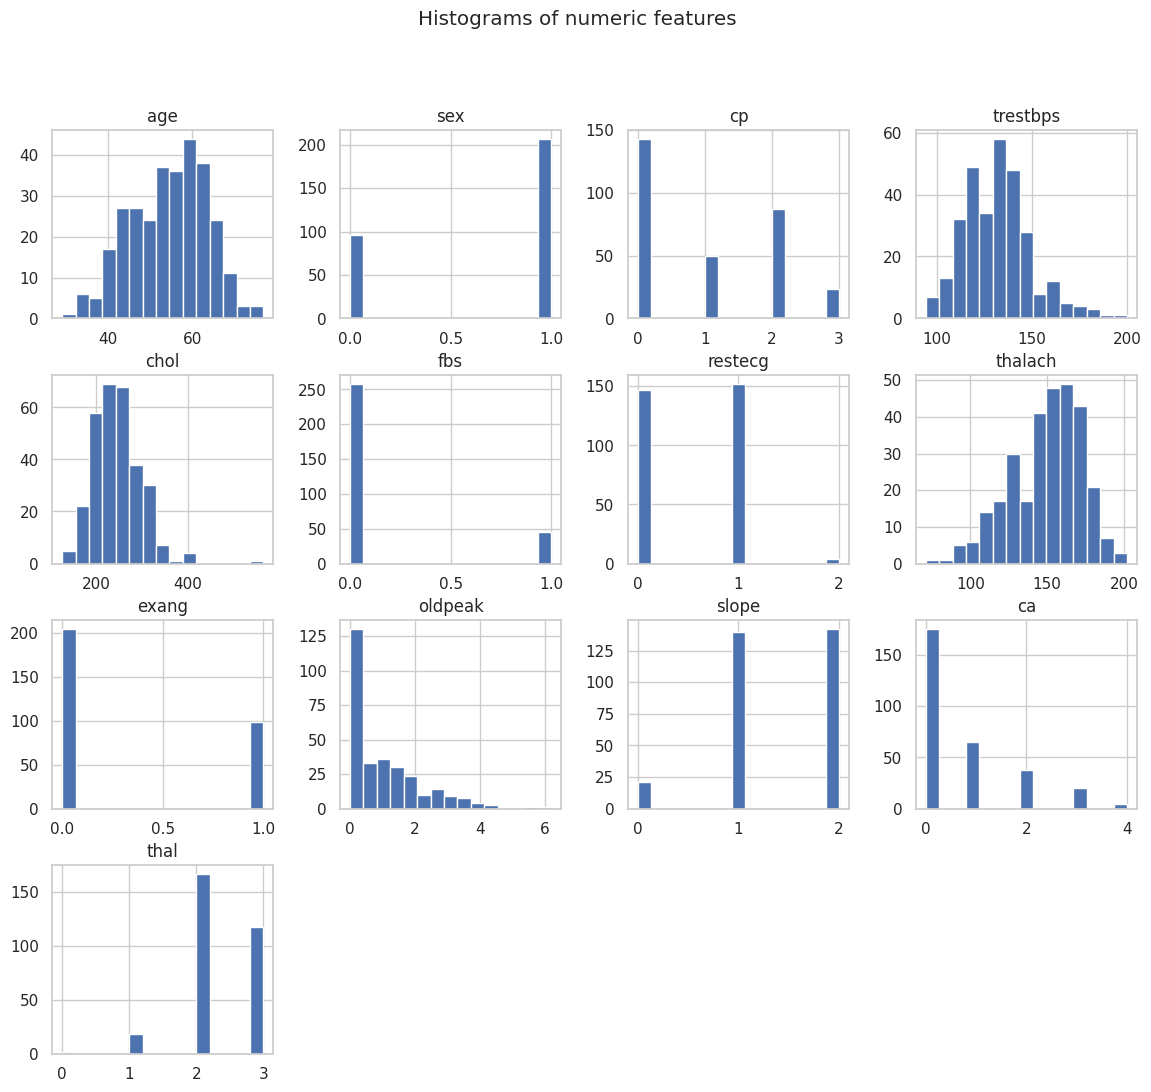

In [ ]:
# Histograms for numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'target' in num_cols:
    num_cols.remove('target')

plt.figure(figsize=(14,10))
df[num_cols].hist(bins=15, layout=(4,4), figsize=(14,12))
plt.suptitle("Histograms of numeric features")
plt.show()


Categorical-like columns used for plotting: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

Value counts for sex:
sex
1    207
0     96
Name: count, dtype: int64


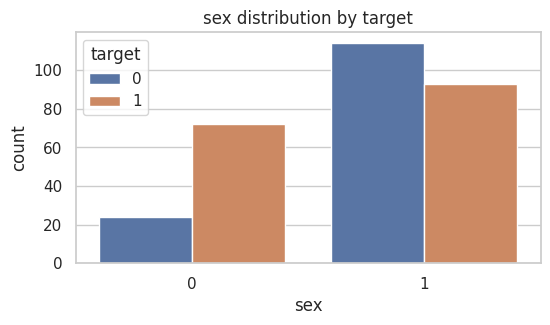


Value counts for cp:
cp
0    143
2     87
1     50
3     23
Name: count, dtype: int64


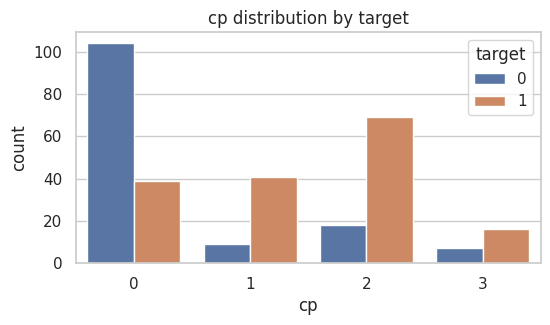


Value counts for fbs:
fbs
0    258
1     45
Name: count, dtype: int64


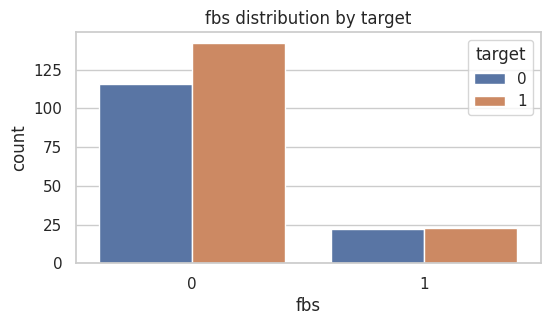


Value counts for restecg:
restecg
1    152
0    147
2      4
Name: count, dtype: int64


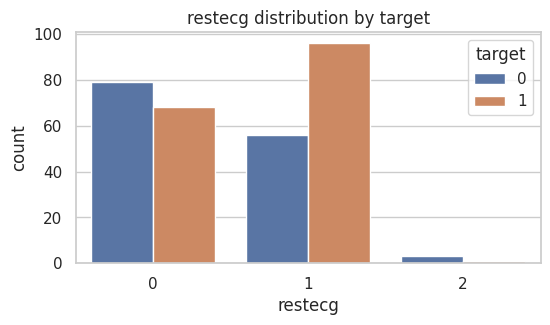


Value counts for exang:
exang
0    204
1     99
Name: count, dtype: int64


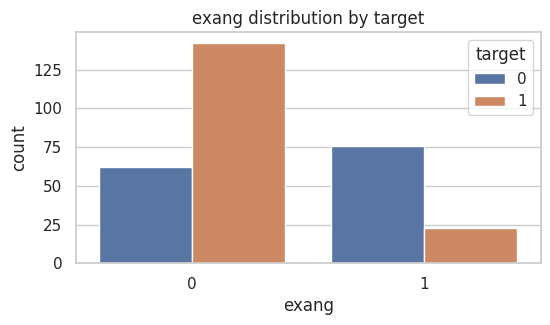


Value counts for slope:
slope
2    142
1    140
0     21
Name: count, dtype: int64


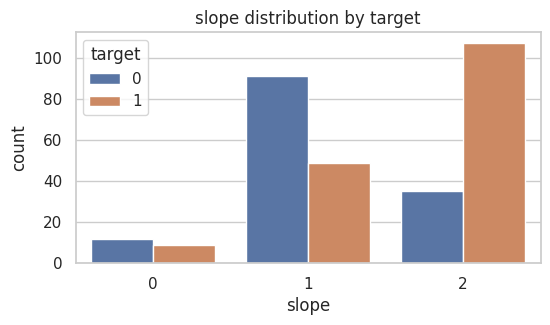


Value counts for ca:
ca
0    175
1     65
2     38
3     20
4      5
Name: count, dtype: int64


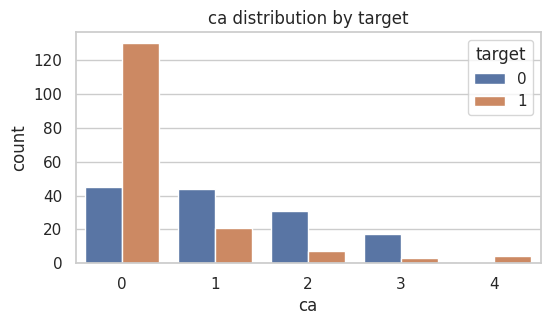


Value counts for thal:
thal
2    166
3    117
1     18
0      2
Name: count, dtype: int64


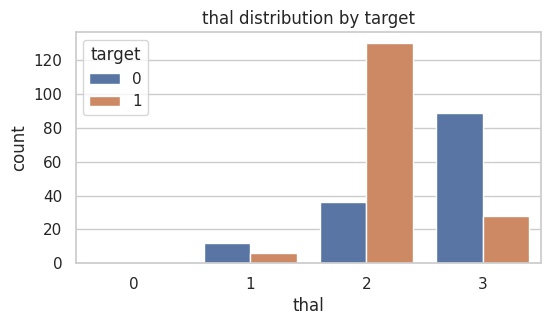

In [ ]:
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
print("Categorical-like columns used for plotting:", cat_cols)

for c in cat_cols:
    if c in df.columns:
        print(f"\nValue counts for {c}:")
        print(df[c].value_counts())
        plt.figure(figsize=(6,3))
        sns.countplot(data=df, x=c, hue='target')
        plt.title(f"{c} distribution by target")
        plt.show()


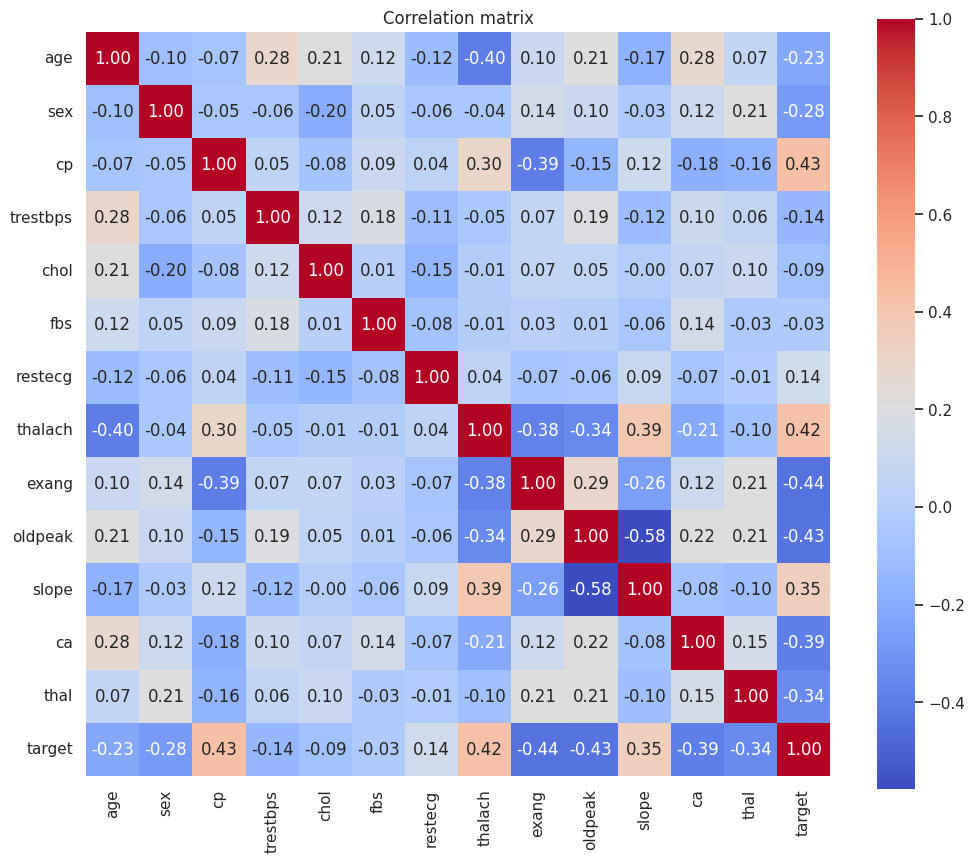

Look for features strongly correlated with 'target' and potential multicollinearity.


In [ ]:
plt.figure(figsize=(12,10))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation matrix")
plt.show()

print("Look for features strongly correlated with 'target' and potential multicollinearity.")


In [ ]:
print("Checking for any non-numeric or unusual encodings:")
for col in df.columns:
    if df[col].dtype == object:
        print(col, df[col].unique()[:20])

print("\nCheck for zeros or impossible values in columns that should be positive (like 'thal' sometimes 0):")
for c in ['thal','ca']:
    if c in df.columns:
        print(c, "unique values:", sorted(df[c].unique()))

print("\nIf any '?' or string placeholders are present, we should replace them and convert columns to numeric. This dataset looks numeric-clean.")


Checking for any non-numeric or unusual encodings:

Check for zeros or impossible values in columns that should be positive (like 'thal' sometimes 0):
thal unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
ca unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

If any '?' or string placeholders are present, we should replace them and convert columns to numeric. This dataset looks numeric-clean.


In [ ]:
# Prepare X and y
X = df.drop(columns=['target'])
y = df['target']

# Choose columns to one-hot encode (cp, thal, slope) as per project plan
onehot_cols = [c for c in ['cp','thal','slope'] if c in X.columns]
# Numerical columns = all remaining columns
num_cols = [c for c in X.columns if c not in onehot_cols]

print("One-hot columns:", onehot_cols)
print("Numerical columns:", num_cols)

# ColumnTransformer: scale numeric, one-hot encode chosen categorical
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('ohe', OneHotEncoder(drop='first', sparse_output=False), onehot_cols)
], remainder='passthrough')  # passthrough in case any others remain (shouldn't)

# Fit the preprocessor and transform to inspect shape
X_pre = preprocessor.fit_transform(X)
print("Preprocessing done. Transformed shape:", X_pre.shape)

# Build final feature names list for interpretation
ohe = preprocessor.named_transformers_['ohe']
ohe_cols = list(ohe.get_feature_names_out(onehot_cols)) if len(onehot_cols)>0 else []
feature_names = num_cols + ohe_cols
print("Sample feature names (first 20):", feature_names[:20])

One-hot columns: ['cp', 'thal', 'slope']
Numerical columns: ['age', 'sex', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'ca']
Preprocessing done. Transformed shape: (303, 18)
Sample feature names (first 20): ['age', 'sex', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'ca', 'cp_1', 'cp_2', 'cp_3', 'thal_1', 'thal_2', 'thal_3', 'slope_1', 'slope_2']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_pre, y, test_size=0.2, random_state=RSEED, stratify=y)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train target distribution:\n", np.bincount(y_train))
print("Test target distribution:\n", np.bincount(y_test))


Train shape: (242, 18) Test shape: (61, 18)
Train target distribution:
 [110 132]
Test target distribution:
 [28 33]


In [ ]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test, show_confusion=True):
    print(f"\n>>> Evaluating: {name}")
    # prediction
    y_pred = None
    y_proba = None

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:,1]
        y_pred = (y_proba > 0.5).astype(int)
    elif isinstance(model, tf.keras.Model): # Specifically handle Keras models
        y_proba = np.ravel(model.predict(X_test))
        y_pred = (y_proba > 0.5).astype(int)
    else:
        y_pred = model.predict(X_test)
        # If it's a model that doesn't have predict_proba but predict gives scores/continuous output, try to binarize
        if y_pred.dtype == float or y_pred.dtype == np.float32 or y_pred.dtype == np.float64:
            y_proba = np.ravel(y_pred)
            y_pred = (y_proba > 0.5).astype(int)

    # Ensure y_pred is binarized for metrics
    if y_pred is None or not (np.isin(y_pred, [0, 1]).all()): # If prediction is not already binary
        raise ValueError("Model prediction output could not be binarized for evaluation.")

    # metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    # roc
    roc = None
    try:
        # Reuse y_proba if already calculated, otherwise calculate it
        if y_proba is not None:
            roc = roc_auc_score(y_test, y_proba)
        elif hasattr(model, "predict_proba"):
            roc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
        else: # For models like Keras where predict returns probabilities
            roc = roc_auc_score(y_test, np.ravel(model.predict(X_test)))
    except Exception: # Fallback if ROC calculation fails for any reason
        roc = None

    print("Accuracy:", round(acc,4))
    print("Precision:", round(prec,4))
    print("Recall:", round(rec,4))
    print("F1-score:", round(f1,4))
    print("ROC-AUC:", round(roc,4) if roc is not None else "N/A")
    print("\nClassification report:")
    print(classification_report(y_test, y_pred))
    if show_confusion:
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(4,3))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f"Confusion matrix: {name}")
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()
    return {'accuracy':acc, 'precision':prec, 'recall':rec, 'f1':f1, 'roc':roc}

Training Logistic Regression...

>>> Evaluating: Logistic Regression
Accuracy: 0.8033
Precision: 0.7838
Recall: 0.8788
F1-score: 0.8286
ROC-AUC: 0.8885

Classification report:
              precision    recall  f1-score   support

           0       0.83      0.71      0.77        28
           1       0.78      0.88      0.83        33

    accuracy                           0.80        61
   macro avg       0.81      0.80      0.80        61
weighted avg       0.81      0.80      0.80        61



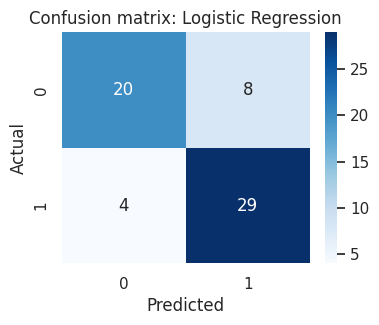

Training Decision Tree...

>>> Evaluating: Decision Tree
Accuracy: 0.7213
Precision: 0.7222
Recall: 0.7879
F1-score: 0.7536
ROC-AUC: 0.7154

Classification report:
              precision    recall  f1-score   support

           0       0.72      0.64      0.68        28
           1       0.72      0.79      0.75        33

    accuracy                           0.72        61
   macro avg       0.72      0.72      0.72        61
weighted avg       0.72      0.72      0.72        61



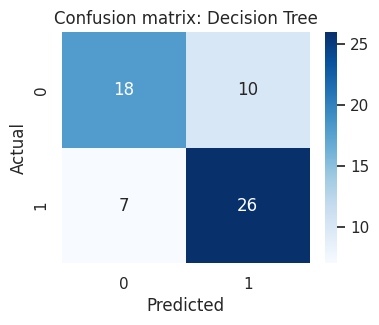

Training Random Forest (100 trees)...

>>> Evaluating: Random Forest (base)
Accuracy: 0.7705
Precision: 0.7436
Recall: 0.8788
F1-score: 0.8056
ROC-AUC: 0.9134

Classification report:
              precision    recall  f1-score   support

           0       0.82      0.64      0.72        28
           1       0.74      0.88      0.81        33

    accuracy                           0.77        61
   macro avg       0.78      0.76      0.76        61
weighted avg       0.78      0.77      0.77        61



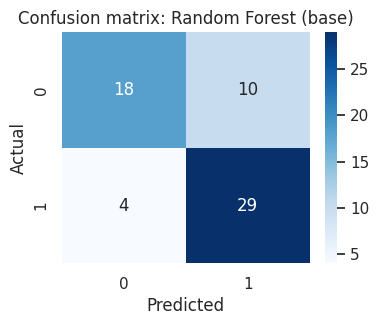

In [ ]:
# Logistic Regression
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=RSEED)
lr.fit(X_train, y_train)
lr_metrics = evaluate_model("Logistic Regression", lr, X_train, y_train, X_test, y_test)

# Decision Tree
print("Training Decision Tree...")
dt = DecisionTreeClassifier(random_state=RSEED)
dt.fit(X_train, y_train)
dt_metrics = evaluate_model("Decision Tree", dt, X_train, y_train, X_test, y_test)

# Random Forest baseline
print("Training Random Forest (100 trees)...")
rf = RandomForestClassifier(n_estimators=100, random_state=RSEED)
rf.fit(X_train, y_train)
rf_metrics = evaluate_model("Random Forest (base)", rf, X_train, y_train, X_test, y_test)


Hyperparameter tuning (RandomizedSearchCV) for RandomForest — may take a few minutes.
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}

>>> Evaluating: Random Forest (tuned)
Accuracy: 0.7705
Precision: 0.7436
Recall: 0.8788
F1-score: 0.8056
ROC-AUC: 0.9102

Classification report:
              precision    recall  f1-score   support

           0       0.82      0.64      0.72        28
           1       0.74      0.88      0.81        33

    accuracy                           0.77        61
   macro avg       0.78      0.76      0.76        61
weighted avg       0.78      0.77      0.77        61



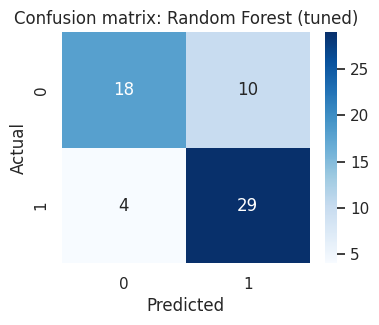

In [ ]:
print("Hyperparameter tuning (RandomizedSearchCV) for RandomForest — may take a few minutes.")
param_dist = {
    'n_estimators': [50,100,200,300],
    'max_depth': [None,5,10,20],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4],
    'max_features': ['sqrt','log2', None]
}
rf_clf = RandomForestClassifier(random_state=RSEED)
rand_search = RandomizedSearchCV(rf_clf, param_distributions=param_dist, n_iter=20, scoring='roc_auc', cv=5, random_state=RSEED, n_jobs=-1, verbose=1)
rand_search.fit(X_train, y_train)
print("Best params:", rand_search.best_params_)
best_rf = rand_search.best_estimator_
rf_tuned_metrics = evaluate_model("Random Forest (tuned)", best_rf, X_train, y_train, X_test, y_test)


Training a simple feedforward neural network (Keras).


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4971 - loss: 0.7663 - val_accuracy: 0.5102 - val_loss: 0.7134
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5788 - loss: 0.6711 - val_accuracy: 0.7143 - val_loss: 0.5810
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7984 - loss: 0.5254 - val_accuracy: 0.7959 - val_loss: 0.5007
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7637 - loss: 0.5294 - val_accuracy: 0.8163 - val_loss: 0.4466
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7952 - loss: 0.4801 - val_accuracy: 0.8367 - val_loss: 0.4065
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8245 - loss: 0.4072 - val_accuracy: 0.8163 - val_loss: 0.3690
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8326 - loss: 0.4068 - val_accuracy: 0.8163 - val_loss: 0.3461
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8772 - loss: 0.3639 - val_accuracy: 0.8367 -

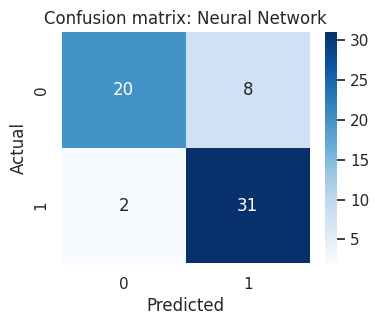

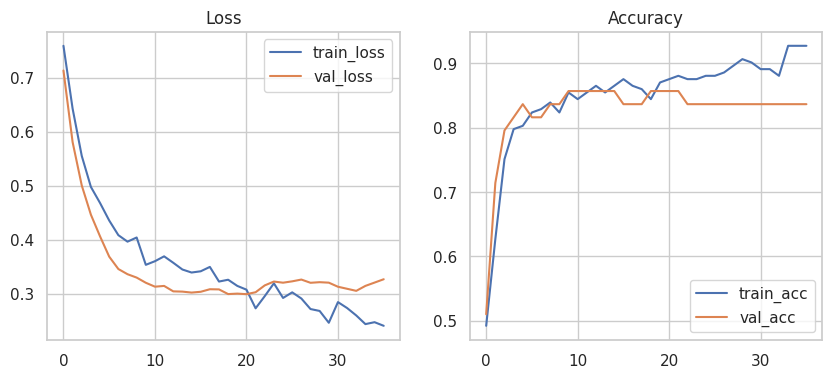

In [ ]:
print("Training a simple feedforward neural network (Keras).")

input_dim = X_train.shape[1]

def build_simple_nn(input_dim):
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(input_dim,)))
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

nn_model = build_simple_nn(input_dim)
nn_model.summary()

es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
# Keras expects arrays
history = nn_model.fit(X_train, y_train, validation_split=0.2, epochs=200, batch_size=16, callbacks=[es], verbose=1)

# Evaluate using our function
nn_metrics = evaluate_model("Neural Network", nn_model, X_train, y_train, X_test, y_test)

# Plot training history
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.legend()
plt.show()


In [ ]:
results = pd.DataFrame({
    'model': ['Logistic Regression', 'Decision Tree', 'Random Forest (base)', 'Random Forest (tuned)', 'Neural Network'],
    'accuracy': [lr_metrics['accuracy'], dt_metrics['accuracy'], rf_metrics['accuracy'], rf_tuned_metrics['accuracy'], nn_metrics['accuracy']],
    'precision': [lr_metrics['precision'], dt_metrics['precision'], rf_metrics['precision'], rf_tuned_metrics['precision'], nn_metrics['precision']],
    'recall': [lr_metrics['recall'], dt_metrics['recall'], rf_metrics['recall'], rf_tuned_metrics['recall'], nn_metrics['recall']],
    'f1': [lr_metrics['f1'], dt_metrics['f1'], rf_metrics['f1'], rf_tuned_metrics['f1'], nn_metrics['f1']],
    'roc_auc': [lr_metrics['roc'], dt_metrics['roc'], rf_metrics['roc'], rf_tuned_metrics['roc'], nn_metrics['roc']]
})
print("Model comparison (sorted by ROC-AUC):")
display(results.sort_values(by='roc_auc', ascending=False).round(4))


Model comparison (sorted by ROC-AUC):


,model,accuracy,precision,recall,f1,roc_auc
2,Random Forest (base),0.7705,0.7436,0.8788,0.8056,0.9134
3,Random Forest (tuned),0.7705,0.7436,0.8788,0.8056,0.9102
4,Neural Network,0.8361,0.7949,0.9394,0.8611,0.9015
0,Logistic Regression,0.8033,0.7838,0.8788,0.8286,0.8885
1,Decision Tree,0.7213,0.7222,0.7879,0.7536,0.7154


Top 15 features by RandomForest importance:


,0
thal_2,0.141509
thalach,0.103923
ca,0.102263
oldpeak,0.096030
thal_3,0.092974
exang,0.083771
slope_2,0.074685
chol,0.060997
age,0.060950
trestbps,0.047393


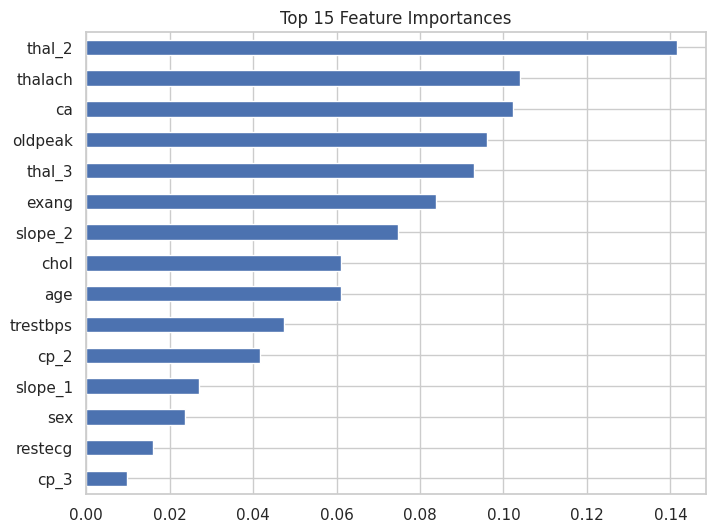


Top features by absolute LogisticRegression coefficient:


,0
cp_2,1.435292
cp_3,1.279855
thal_3,-0.845484
thal_2,0.748302
cp_1,0.732775
chol,-0.567438
ca,-0.540689
sex,-0.510295
exang,-0.468281
oldpeak,-0.440787


In [ ]:
# RandomForest feature importances
try:
    importances = best_rf.feature_importances_
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)
    print("Top 15 features by RandomForest importance:")
    display(fi.head(15))
    plt.figure(figsize=(8,6))
    fi.head(15).plot(kind='barh')
    plt.gca().invert_yaxis()
    plt.title("Top 15 Feature Importances")
    plt.show()
except Exception as e:
    print("Could not extract feature importances from RandomForest:", e)

# Logistic regression coefficients (linear importance)
try:
    coefs = lr.coef_.ravel()
    coef_ser = pd.Series(coefs, index=feature_names).sort_values(key=lambda x: np.abs(x), ascending=False)
    print("\nTop features by absolute LogisticRegression coefficient:")
    display(coef_ser.head(15))
except Exception as e:
    print("LogisticRegression coefficients extraction failed:", e)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step 


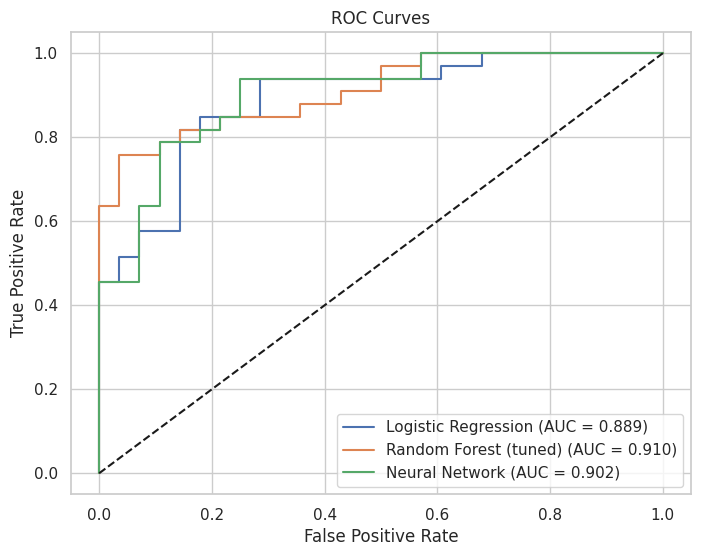

In [ ]:
plt.figure(figsize=(8,6))

def get_proba(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:,1]
    else:
        return np.ravel(model.predict(X))

models_for_roc = {
    'Logistic Regression': lr,
    'Random Forest (tuned)': best_rf,
}

for name, model in models_for_roc.items():
    y_proba = get_proba(model, X_test)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_proba):.3f})")

# NN
try:
    y_proba_nn = np.ravel(nn_model.predict(X_test))
    fpr, tpr, _ = roc_curve(y_test, y_proba_nn)
    plt.plot(fpr, tpr, label=f"Neural Network (AUC = {roc_auc_score(y_test, y_proba_nn):.3f})")
except Exception as e:
    print("NN ROC error:", e)

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()


In [ ]:
# Example single patient (use columns order from original X)
example_patient = {
    # Provide realistic example values — adjust as needed
    'age': 56, 'sex': 1, 'cp': 2, 'trestbps': 130, 'chol': 236, 'fbs': 0,
    'restecg': 1, 'thalach': 178, 'exang': 0, 'oldpeak': 0.8, 'slope': 2, 'ca': 0, 'thal': 2
}

# Create DataFrame row in same column order
example_df = pd.DataFrame([example_patient])[X.columns]
print("Example patient row:")
display(example_df)

# Transform using preprocessor and predict with best model
example_X = preprocessor.transform(example_df)
pred_rf = best_rf.predict(example_X)[0]
prob_rf = best_rf.predict_proba(example_X)[:,1][0]
print(f"RandomForest prediction: {pred_rf} (1 = disease, 0 = no disease). Probability: {prob_rf:.3f}")

pred_lr = lr.predict(example_X)[0]
prob_lr = lr.predict_proba(example_X)[:,1][0]
print(f"LogisticRegression prediction: {pred_lr} Probability: {prob_lr:.3f}")

pred_nn = (np.ravel(nn_model.predict(example_X)) > 0.5).astype(int)[0]
prob_nn = np.ravel(nn_model.predict(example_X))[0]
print(f"NeuralNetwork prediction: {pred_nn} Probability: {prob_nn:.3f}")


Example patient row:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,56,1,2,130,236,0,1,178,0,0.8,2,0,2


RandomForest prediction: 1 (1 = disease, 0 = no disease). Probability: 0.966
LogisticRegression prediction: 1 Probability: 0.964
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
NeuralNetwork prediction: 1 Probability: 0.959


In [ ]:
model_dir = "models"
os.makedirs(model_dir, exist_ok=True)

joblib.dump(best_rf, os.path.join(model_dir, "best_random_forest.joblib"))
print("Saved best_random_forest.joblib")
joblib.dump(lr, os.path.join(model_dir, "logistic_regression.joblib"))
print("Saved logistic_regression.joblib")
joblib.dump(preprocessor, os.path.join(model_dir, "preprocessor.joblib"))
print("Saved preprocessor.joblib")
nn_model.save(os.path.join(model_dir, "nn_model.h5"))
print("Saved nn_model.h5")

print(f"All artifacts saved in folder: {model_dir} (download from Colab Files panel).")


Saved best_random_forest.joblib
Saved logistic_regression.joblib
Saved preprocessor.joblib
Saved nn_model.h5
All artifacts saved in folder: models (download from Colab Files panel).


In [ ]:
print("PROJECT SUMMARY — Student-style conclusions:\n")
print("1) Problem: Predict heart disease (binary) using clinical features.")
print("2) Data: heart.csv loaded. Checked data, no major missing values found.")
print("3) EDA: Explored distributions, categorical relationships, and correlations.")
print("4) Preprocessing: One-hot encoded cp, thal, slope; scaled numeric features with StandardScaler.")
print("5) Models trained: Logistic Regression, Decision Tree, Random Forest (base + tuned), Neural Network.")
print("6) Tuning: RandomizedSearchCV performed for RandomForest.")
print("7) Evaluation: Accuracy, Precision, Recall, F1, ROC-AUC, confusion matrices, ROC curves.")
print("8) Interpretation: Feature importances from RandomForest and coefficients from LogisticRegression shown.")
print("9) Example inference: Showed how to predict for a new single patient using the preprocessor + model.")
print("10) Artifacts: Saved models and preprocessor for later inference or deployment.")
print("\nLimitations to mention in your report:")
print("- Dataset size (~303 rows) — risk of overfitting and limited generalization.")
print("- No external cohort validation included.")
print("- Preprocessing choices (which columns to one-hot) were decided for simplicity; alternative encodings possible.")
print("\nNext steps (if you want): add SHAP explanations, nested CV, class imbalance methods (SMOTE), or deployment. Tell me which and I'll add it.")


PROJECT SUMMARY — Student-style conclusions:

1) Problem: Predict heart disease (binary) using clinical features.
2) Data: heart.csv loaded. Checked data, no major missing values found.
3) EDA: Explored distributions, categorical relationships, and correlations.
4) Preprocessing: One-hot encoded cp, thal, slope; scaled numeric features with StandardScaler.
5) Models trained: Logistic Regression, Decision Tree, Random Forest (base + tuned), Neural Network.
6) Tuning: RandomizedSearchCV performed for RandomForest.
7) Evaluation: Accuracy, Precision, Recall, F1, ROC-AUC, confusion matrices, ROC curves.
8) Interpretation: Feature importances from RandomForest and coefficients from LogisticRegression shown.
9) Example inference: Showed how to predict for a new single patient using the preprocessor + model.
10) Artifacts: Saved models and preprocessor for later inference or deployment.

Limitations to mention in your report:
- Dataset size (~303 rows) — risk of overfitting and limited genera

In [ ]:
# ===========================================
# HEART DISEASE PREDICTION – GRADIO APP (HF Spaces Ready)
# ===========================================

!pip install gradio joblib -q

import gradio as gr
import pandas as pd
import joblib
from sklearn.pipeline import Pipeline

# Re-load the preprocessor and the best_rf model
preprocessor = joblib.load("models/preprocessor.joblib")
best_rf = joblib.load("models/best_random_forest.joblib")

# Create a pipeline that includes preprocessing and the model
# The ColumnTransformer must be part of the pipeline to process raw inputs
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', best_rf)
])

# Save the pipeline so Gradio can load it by name
joblib.dump(model_pipeline, "models/best_random_forest_pipeline.joblib")
print("Saved models/best_random_forest_pipeline.joblib")

# Load saved RF pipeline
model = joblib.load("models/best_random_forest_pipeline.joblib")

def predict_heart_disease(age, sex, cp, trestbps, chol, fbs, restecg,
                          thalach, exang, oldpeak, slope, ca, thal):

    # Create input dataframe - ensure column order matches original X
    input_data = pd.DataFrame([{
        "age": age,
        "sex": sex,
        "cp": cp,
        "trestbps": trestbps,
        "chol": chol,
        "fbs": fbs,
        "restecg": restecg,
        "thalach": thalach,
        "exang": exang,
        "oldpeak": oldpeak,
        "slope": slope,
        "ca": ca,
        "thal": thal
    }])

    # Predict using saved pipeline (preprocessing is handled internally by the pipeline)
    proba = model.predict_proba(input_data)[0][1]
    label = int(proba >= 0.5)

    return {
        "Probability of Heart Disease": float(proba),
        "Prediction (0=No, 1=Yes)": label
    }


# Gradio UI - Simplified inputs to directly take numerical values
inputs = [
    gr.Number(label="Age"),
    gr.Radio([0, 1], label="Sex (0=Female, 1=Male)"),
    gr.Radio([0, 1, 2, 3], label="Chest Pain Type (cp)"),
    gr.Number(label="Resting BP (trestbps)"),
    gr.Number(label="Cholesterol (chol)"),
    gr.Radio([0, 1], label="Fasting Blood Sugar >120 mg/dl (0=False, 1=True)"),
    gr.Radio([0, 1, 2], label="Resting ECG (restecg)"),
    gr.Number(label="Max Heart Rate (thalach)"),
    gr.Radio([0, 1], label="Exercise Induced Angina (0=No, 1=Yes)"),
    gr.Number(label="ST Depression (oldpeak)"),
    gr.Radio([0, 1, 2], label="Slope of Peak Exercise ST Segment (slope)"),
    gr.Radio([0, 1, 2, 3, 4], label="Number of Major Vessels (ca)"),
    gr.Radio([0, 1, 2, 3], label="Thal (0,1=Normal, 2=Fixed Defect, 3=Reversible Defect)") # Correcting thal input based on EDA (0,1,2,3)
]

output = gr.JSON()

gr.Interface(
    fn=predict_heart_disease,
    inputs=inputs,
    outputs=output,
    title="Heart Disease Prediction App",
    description="A Machine Learning model predicting the probability of heart disease.",
    allow_flagging="never"
).launch(share=True)


Saved models/best_random_forest_pipeline.joblib
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3b1bebe6fe8772af68.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
